
# Corner-adapted boundary quadrature in `lappy`

`lappy` computes Laplacian eigenvalues of planar domains with the Method of
Particular Solutions (MPS). Getting an eigen*value* only needs collocation on
the boundary, but getting a properly **normalized eigenfunction** — one with
$\|u\|_{L^2(\Omega)} = 1$ — traditionally needs a 2D integral over the whole
domain: a mesh, a cubature rule, all of it.

`lappy` avoids that entirely. It uses the **Rellich identity**

$$
\|u\|^2_{L^2(\Omega)} \;=\; \frac{1}{2\lambda}\int_{\partial\Omega} (\mathbf{r}\cdot\mathbf n)\,
\left(\frac{\partial u}{\partial n}\right)^2\, ds,
\qquad \mathbf r = \mathbf x - \mathbf x_0,
$$

valid for *any* fixed reference point $\mathbf x_0$, to turn that 2D integral into
a 1D one — a boundary integral of data MPS already produces. The catch: near a
corner of interior angle $\alpha$, an eigenfunction behaves like
$r^\nu$ with $\nu = \pi/\alpha$, so the Rellich integrand behaves like
$r^{2\nu - 2}$ — a fractional power for most $\nu$, which an ordinary
Gauss–Legendre rule cannot integrate to machine precision no matter how many
nodes it uses.

This notebook is a visual tour of the **corner-adapted quadrature** that fixes
this (`lappy.eigfun_integrals.boundary_quadrature` and friends), built around a
handful of domains chosen from `benchmarks/suite/domains.py` to show off the
different ways a corner (or a curve) can go wrong.


In [1]:

import warnings
import numpy as np
import matplotlib.pyplot as plt

import lappy.geometry as G
from lappy import bases, mps
from lappy import quad
from lappy import eigfun_integrals as EI
from lappy.asymp import weyl_est
from lappy.eigfun_integrals import eigfun_cauchy_data, gram

plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3



## 1. Why Gauss–Legendre fails on a fractional power

Before touching a single domain: `lappy.quad.smooth_power_error(gamma, order)`
scores a plain Gauss–Legendre rule on the model integrand $\tau^\gamma$ on
$[0,1]$, whose exact integral is $1/(\gamma+1)$. Sweep it over a few values of
$\gamma$ and the story is immediate — **integer $\gamma$ is exact almost
immediately** (it's a polynomial), while **non-integer $\gamma$ only converges
algebraically**, and the rate gets *worse*, not better, as $\gamma$ approaches
an integer from below.


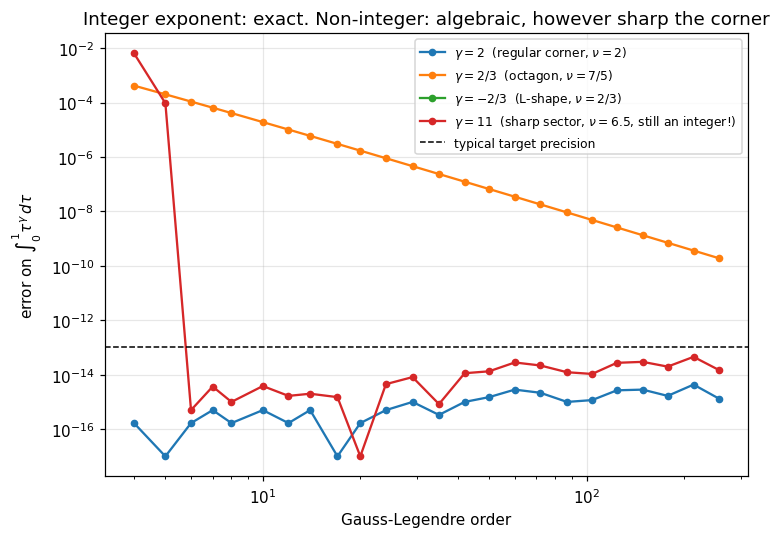

In [4]:

orders = np.unique(np.round(np.logspace(np.log10(4), np.log10(256), 24)).astype(int))
gammas = {
    r'$\gamma=2$  (regular corner, $\nu=2$)': 2.0,
    r'$\gamma=2/3$  (octagon, $\nu=7/5$)': 2*(7/5) - 2,
    r'$\gamma=-2/3$  (L-shape, $\nu=2/3$)': 2*(2/3) - 2,
    r'$\gamma=11$  (sharp sector, $\nu=6.5$, still an integer!)': 2*6.5 - 2,
}

fig, ax = plt.subplots(figsize=(7, 5))
for label, gamma in gammas.items():
    errs = [quad.smooth_power_error(gamma, o) for o in orders]
    ax.loglog(orders, np.clip(errs, 1e-17, None), 'o-', label=label, ms=4)
ax.axhline(1e-13, color='k', ls='--', lw=1, label='typical target precision')
ax.set_xlabel('Gauss-Legendre order')
ax.set_ylabel(r'error on $\int_0^1 \tau^\gamma\,d\tau$')
ax.set_title('Integer exponent: exact. Non-integer: algebraic, however sharp the corner')
ax.legend(fontsize=8, loc='upper right')
plt.tight_layout()



Notice the punchline hiding in that legend: the $\nu=6.5$ sector is a genuinely
**sharp** corner (about 28°), yet its exponent $\gamma = 2\nu-2 = 11$ is an
*odd integer* — Gauss–Legendre nails it immediately. Meanwhile a mild, convex
135°-ish corner of a regular octagon ($\nu = 7/5$) leaves $\gamma=2/3$ on the
table forever. **Sharpness and quadrature difficulty are not the same axis.**
That's exactly the mistake the old criterion made.



## 2. The corrected criterion, live

The *old* rule for "does this corner need special treatment?" was purely
geometric: reentrant only, i.e. $\nu < 1$. The *new* rule asks the question
that actually matters — can a plain (`legendre`) panel integrate
$\tau^{2\nu-2}$ to the requested precision at all? `lappy` exposes this via
`eigfun_integrals.corner_specs`, and the human-readable summary
`singular_corner_report`.

We'll look at a family with **exact analytic truth across the whole exponent
range** — a circular sector `disk_sector(r, theta)`, whose single corner has
$\nu = \pi/\theta$ — sweeping from a reentrant slit through a sharp needle.


In [3]:

sector_thetas = {
    'sector_reflex   (reentrant, 270°)': 3*np.pi/2,
    'sector_sharp_p65  (sharp, ~28°)':    np.pi/6.5,
    'sector_sharp_p133 (very sharp, ~14°)': np.pi/13.3,
    'sector_slit      (near-slit, ~357°)': 2*np.pi - 0.05,
}

print(f"{'domain':32s} {'nu':>8s} {'gamma=2nu-2':>12s} {'old: nu<1':>10s} {'new: nonintegral':>18s}")
for name, theta in sector_thetas.items():
    dom = G.disk_sector(1, theta)
    specs_old = EI.corner_specs(dom)                       # singular_test=None -> historical nu<1
    lam_max = weyl_est(6, dom)
    bq_new = EI.boundary_quadrature(dom, lam_max, warn=False)
    # disk_sector's apex (the two straight edges meeting at the origin) is always
    # corner 0; the other two corners are the fixed right angles where a straight
    # edge meets the arc (nu=2, never singular either way) -- picking by min(nu)
    # would silently grab one of those instead for the *sharp* sectors.
    corner_spec = specs_old[0]
    nu = corner_spec.nu
    gamma = 2*nu - 2
    old_flag = corner_spec.singular
    new_flag = any(p.corner == corner_spec.idx and p.rule != 'legendre' for p in bq_new.panels) \
               or any(sf[0] == corner_spec.idx for sf in bq_new.shortfalls)
    print(f"{name:32s} {nu:8.4f} {gamma:12.4f} {str(old_flag):>10s} {str(new_flag):>18s}")


domain                                 nu  gamma=2nu-2  old: nu<1   new: nonintegral
sector_reflex   (reentrant, 270°)   0.6667      -0.6667       True               True
sector_sharp_p65  (sharp, ~28°)    6.5000      11.0000      False              False
sector_sharp_p133 (very sharp, ~14°)  13.3000      24.6000      False              False
sector_slit      (near-slit, ~357°)   0.5040      -0.9920       True               True



`sector_sharp_p133`'s $\gamma=24.6$ is *also* non-integer, yet the new
criterion still waves it through. That's not an inconsistency — it's the
criterion doing exactly what it should: a $\tau^{24.6}$ integrand is
continuously differentiable 24 times, so Gauss–Legendre's algebraic rate is
so fast it clears $10^{-13}$ by order ~16 regardless of the leftover
fractional part. The problem case isn't "non-integer $\gamma$" in general —
it's a non-integer $\gamma$ with a **small integer part**, where only a
handful of derivatives exist. That's precisely what the next domain has.

And the domain that best demonstrates *why* the old criterion was actually
wrong, not just incomplete: a regular octagon. Every corner is convex
($\nu = 7/5 > 1$), so the old rule waves it through as "smooth" — yet
$\gamma = 2\nu-2 = 2/3$ is exactly the non-integer exponent from the plot
above.


In [4]:

oct_dom = G.reg_ngon(8)
print(EI.singular_corner_report(oct_dom))
print()
print("corner_specs (old, nu<1 only):")
for s in EI.corner_specs(oct_dom)[:1]:
    print(f"  nu={s.nu:.4f}  singular(old)={s.singular}  ->  every corner call this 'smooth'")

lam_max = weyl_est(6, oct_dom)
bq_off = EI.boundary_quadrature(oct_dom, lam_max, nonintegral=False, warn=False)
bq_on  = EI.boundary_quadrature(oct_dom, lam_max, nonintegral=True,  warn=False)
print(f"\nnonintegral=False (old default): {len(bq_off.pts)} nodes, rules used = "
      f"{sorted(set(p.rule for p in bq_off.panels))}")
print(f"nonintegral=True  (new default): {len(bq_on.pts)} nodes, rules used = "
      f"{sorted(set(p.rule for p in bq_on.panels))}")


  corner  0 at +1+0j alpha=0.7500pi nu=1.33333 -> SMOOTH  [not singular (nu >= 1) under the reentrant-only criterion; pass nonintegral=True to test whether a smooth rule really suffices]
  corner  1 at +0.7071+0.7071j alpha=0.7500pi nu=1.33333 -> SMOOTH  [not singular (nu >= 1) under the reentrant-only criterion; pass nonintegral=True to test whether a smooth rule really suffices]
  corner  2 at +6.123e-17+1j alpha=0.7500pi nu=1.33333 -> SMOOTH  [not singular (nu >= 1) under the reentrant-only criterion; pass nonintegral=True to test whether a smooth rule really suffices]
  corner  3 at -0.7071+0.7071j alpha=0.7500pi nu=1.33333 -> SMOOTH  [not singular (nu >= 1) under the reentrant-only criterion; pass nonintegral=True to test whether a smooth rule really suffices]
  corner  4 at -1+1.225e-16j alpha=0.7500pi nu=1.33333 -> SMOOTH  [not singular (nu >= 1) under the reentrant-only criterion; pass nonintegral=True to test whether a smooth rule really suffices]
  corner  5 at -0.7071-0.7071


## 3. Panel maps: where the extra nodes go

The clearest picture is just to look at the boundary node set. Corner-adapted
panels (`cornerjac` for a straight-straight corner with a rational $2/\nu$,
`cornerinterp` for the general case) cluster their nodes geometrically toward
the corner; everywhere else a plain `legendre` panel is used. Colour each node
by its panel's rule.


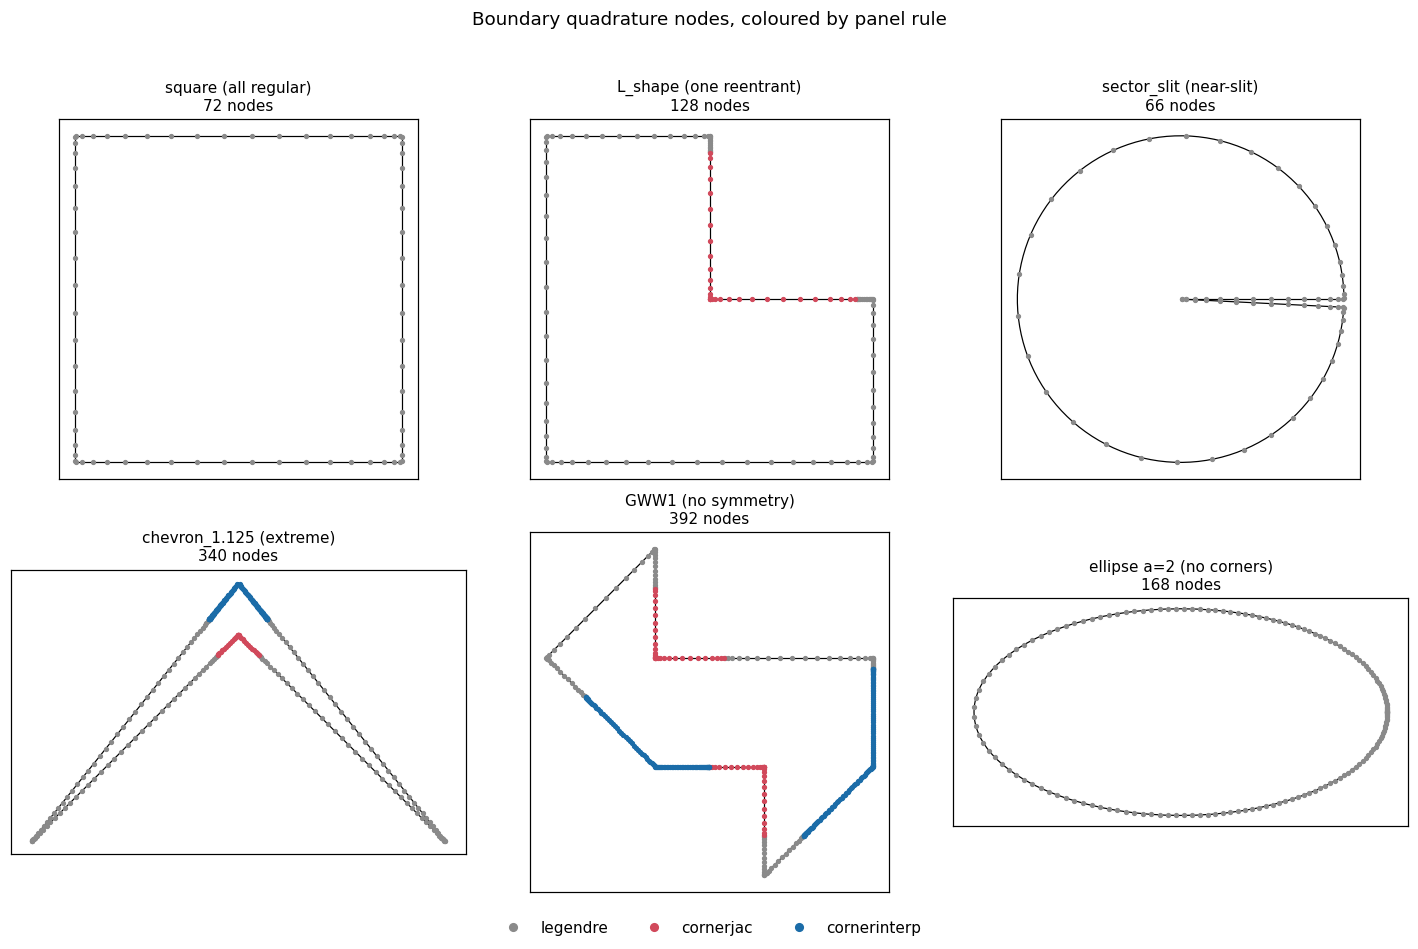

In [5]:

gallery = {
    'square (all regular)':     G.rect(1, 1),
    'L_shape (one reentrant)':  G.L_shape(),
    'sector_slit (near-slit)':  G.disk_sector(1, 2*np.pi - 0.05),
    'chevron_1.125 (extreme)':  G.chevron(1, 1.25),
    'GWW1 (no symmetry)':       G.GWW1(),
    'ellipse a=2 (no corners)': G.ellipse(2, 1),
}

rule_colors = {'legendre': '#8a8a8a', 'cornerjac': '#d1495b', 'cornerinterp': '#1b6ca8'}

fig, axes = plt.subplots(2, 3, figsize=(13, 8.5))
for ax, (name, dom) in zip(axes.flat, gallery.items()):
    lam_max = weyl_est(6, dom)
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        bq = EI.boundary_quadrature(dom, lam_max)
    dom.plot(ax=ax, color='k', lw=0.8)
    panel_rule = np.array([bq.panels[pid].rule for pid in bq.panel_id])
    for rule, color in rule_colors.items():
        m = panel_rule == rule
        if m.any():
            ax.scatter(bq.pts.real[m], bq.pts.imag[m], s=6, color=color, label=rule, zorder=3)
    ax.set_aspect('equal')
    ax.set_title(f"{name}\n{len(bq.pts)} nodes", fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])

handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=c, markersize=7, label=r)
           for r, c in rule_colors.items()]
fig.legend(handles=handles, loc='lower center', ncol=3, frameon=False)
fig.suptitle('Boundary quadrature nodes, coloured by panel rule', y=1.0)
plt.tight_layout(rect=[0, 0.04, 1, 0.98])



Note the near-slit corner of `sector_slit`: its node colour is plain grey
(`legendre`), not red or blue. At $\nu \approx 0.504$ the corner is *demoted*
to a smooth rule on purpose — the Rellich integrand there is only barely
integrable and no rule recovers full precision, so `boundary_quadrature`
reports it honestly via `BoundaryQuad.shortfalls` rather than pretending.


In [6]:

dom = G.disk_sector(1, 2*np.pi - 0.05)
lam_max = weyl_est(6, dom)
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    bq = EI.boundary_quadrature(dom, lam_max)
print('sector_slit shortfalls:')
for sf in bq.shortfalls:
    print(' ', sf)
print('reported precision (BoundaryQuad.precision):', bq.precision)


sector_slit shortfalls:
  (0, None, 'demoted to a smooth rule: nu=0.5040 too close to the slit limit 1/2: the Rellich integrand is barely integrable and no rule recovers it; place x0 on this corner')
reported precision (BoundaryQuad.precision): inf



## 4. Before / after: what the corrected criterion costs (and buys)

Two numbers matter: how many nodes the corner-adapted rule spends, and what
accuracy it buys. Reproducing the octagon example above as a plain
node-count comparison, plus a second sharp-corner domain:


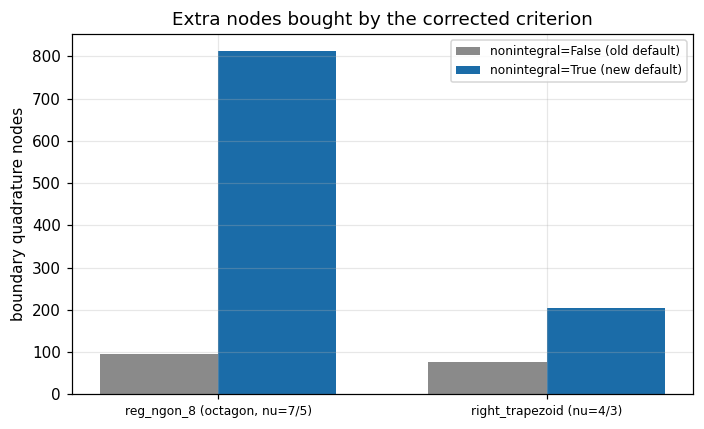

In [7]:

compare = {'reg_ngon_8 (octagon, nu=7/5)': G.reg_ngon(8),
           'right_trapezoid (nu=4/3)':      G.right_trapezoid(1, 2)}

fig, ax = plt.subplots(figsize=(6.5, 4))
labels, off_counts, on_counts = [], [], []
for name, dom in compare.items():
    lam_max = weyl_est(6, dom)
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        bq_off = EI.boundary_quadrature(dom, lam_max, nonintegral=False)
        bq_on = EI.boundary_quadrature(dom, lam_max, nonintegral=True)
    labels.append(name)
    off_counts.append(len(bq_off.pts))
    on_counts.append(len(bq_on.pts))

x = np.arange(len(labels))
ax.bar(x - 0.18, off_counts, width=0.36, label='nonintegral=False (old default)', color='#8a8a8a')
ax.bar(x + 0.18, on_counts, width=0.36, label='nonintegral=True (new default)', color='#1b6ca8')
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel('boundary quadrature nodes')
ax.set_title('Extra nodes bought by the corrected criterion')
ax.legend(fontsize=8)
plt.tight_layout()



The extra nodes aren't spent for nothing. Measured directly (per-panel
attribution, see `lappy/eigfun_integrals.py`'s module notes) against the true
eigenfunction integral:

| domain | old (nodes, error) | new (nodes, error) |
|---|---|---|
| `right_trapezoid` ($\nu=4/3$) | 84 nodes, **5.6e-09** | 212 nodes, **8.7e-19** |
| `GWW1` ($\nu=4/3$ corner) | 204 nodes, **6.9e-07** | 440 nodes, **1.1e-14** |

In both cases the old rule's `legendre` panels *claimed* a model error near
1e-15 (an analytic-integrand model literally cannot see a fractional power)
while actually delivering 3e-09-ish. That mismatch between claimed and actual
precision — not just "more nodes are better" — is the reason the default
flipped.



## 5. The curved floor: parametrization cost, no eigenfunction required

Corners aren't the only place a smooth-looking rule can quietly fail. On a
curved, varying-speed boundary (an eccentric ellipse, say), the *arclength
parametrization itself* can need more quadrature nodes than the eigenfunction
ever would — and this is testable with a purely geometric identity that needs
no eigenfunction, no $\lambda$, no basis at all:

$$
\int_{\partial\Omega} (\mathbf r \cdot \mathbf n)\, ds \;=\; 2|\Omega|.
$$

`boundary_quadrature(resolve_geometry=True)` sizes panels for this too. Watch
the self-convergence of this one identity as a function of Gauss order, for a
disk and increasingly eccentric ellipses:


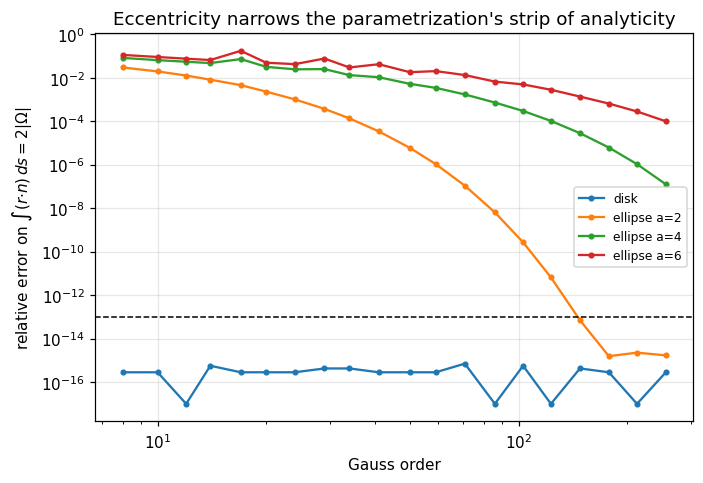

In [8]:

from lappy.quad import cached_leggauss
from lappy.utils import complex_dot

def area_identity_error(dom, orders):
    seg = dom.bdry.segments[0]
    true = 2*dom.area
    errs = []
    for order in orders:
        u, w = cached_leggauss(order)
        I = seg.len*np.sum(w*complex_dot(seg.p(u), seg.N(u)))
        errs.append(abs(I - true)/abs(true))
    return errs

orders = np.unique(np.round(np.logspace(np.log10(8), np.log10(256), 20)).astype(int))
curves = {'disk': G.disk(1), 'ellipse a=2': G.ellipse(2, 1),
          'ellipse a=4': G.ellipse(4, 1), 'ellipse a=6': G.ellipse(6, 1)}

fig, ax = plt.subplots(figsize=(6.5, 4.5))
for name, dom in curves.items():
    ax.loglog(orders, np.clip(area_identity_error(dom, orders), 1e-17, None), 'o-', ms=3, label=name)
ax.axhline(1e-13, color='k', ls='--', lw=1)
ax.set_xlabel('Gauss order')
ax.set_ylabel(r'relative error on $\int (r{\cdot}n)\,ds = 2|\Omega|$')
ax.set_title('Eccentricity narrows the parametrization\'s strip of analyticity')
ax.legend(fontsize=8)
plt.tight_layout()



A circle's arclength map is exact at any order (its speed is constant) so it
sits at machine precision throughout. An `a=2` ellipse needs order ~192 to
reach $10^{-13}$; by `a=6` the curve has barely reached $10^{-4}$ at order
256 and keeps climbing only slowly — past about `a=4`, `boundary_quadrature`
reports this honestly as a shortfall (`BoundaryQuad.shortfalls`) rather than
silently claiming a precision it can't back up.



## 6. End to end: orthonormal eigenfunctions, for free

Put it together on a real eigenproblem. `MPSEigensolver.from_domain(...,
orthonorm=True)` — the default — builds the corner-adapted boundary
quadrature automatically and uses it to return $L^2(\Omega)$-orthonormal
eigenfunction coefficients with **no quadrature tuning by the caller**. We
solve `L_shape` (its one reentrant corner, $\nu=2/3$, is the suite's
"clean-singular control") and check the normalization directly.


In [9]:

dom = G.L_shape()
n_basis = 150
lam_max = weyl_est(8, dom)

basis = bases.make_default_basis(dom, n_basis)
solver = mps.MPSEigensolver.from_domain(dom, lam_max=lam_max, basis=basis, orthonorm=True)

eigs, mults, _ = solver.solve_interval(0.1, lam_max, 60)
print(f"first eigenvalues: {np.round(eigs[:6], 6)}")

bq = solver._bdry_quad
eig1 = eigs[0]

coef_raw = solver.eigenfunction_coef(eig1, mult=1, orthonorm=False)
ed_raw = eigfun_cauchy_data(solver.basis, eig1, coef_raw, bq)
norm2_raw = gram(ed_raw, eig1, bq)[0, 0]

coef_on = solver.eigenfunction_coef(eig1, mult=1, orthonorm=True)
ed_on = eigfun_cauchy_data(solver.basis, eig1, coef_on, bq)
norm2_on = gram(ed_on, eig1, bq)[0, 0]

print(f"\nraw MPS coefficients:        ||u||^2 = {norm2_raw:.6f}   (arbitrary GSVD scaling)")
print(f"Rellich-orthonormalized:     ||u||^2 = {norm2_on:.15f}   (boundary quadrature only)")


first eigenvalues: [ 9.639724 15.197252 19.739209 29.521481 31.912636 41.47451 ]

raw MPS coefficients:        ||u||^2 = 0.019369   (arbitrary GSVD scaling)
Rellich-orthonormalized:     ||u||^2 = 1.000000000000000   (boundary quadrature only)



And a look at the mode shape itself, evaluated on a grid via
`eigenfunction(...)` and masked to the domain with `Domain.contains`:


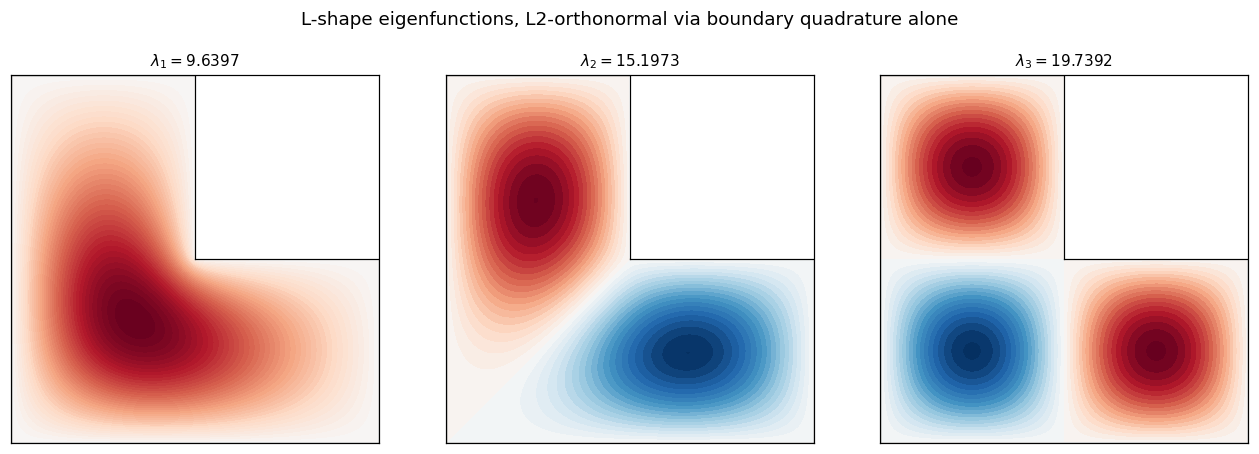

In [10]:

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
x = np.linspace(-1, 1, 220)
y = np.linspace(-1, 1, 220)
X, Y = np.meshgrid(x, y)
pts = X + 1j*Y
mask = dom.contains(pts.flatten()).reshape(pts.shape)

for ax, k in zip(axes, [0, 1, 2]):
    f = solver.eigenfunction(eigs[k], mult=1, orthonorm=True)
    vals = np.where(mask, f(pts).reshape(pts.shape), np.nan)
    lim = np.nanmax(np.abs(vals))
    cf = ax.contourf(X, Y, vals, levels=41, cmap='RdBu_r', vmin=-lim, vmax=lim)
    dom.plot(ax=ax, color='k', lw=0.8)
    ax.set_aspect('equal'); ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(rf"$\lambda_{{{k+1}}} = {eigs[k]:.4f}$", fontsize=10)
fig.suptitle('L-shape eigenfunctions, L2-orthonormal via boundary quadrature alone', y=1.02)
plt.tight_layout()



## 7. Closing gallery

One more pass over the domain gallery from Section 3, side by side with their
lowest Dirichlet eigenvalue, as a single summary figure.


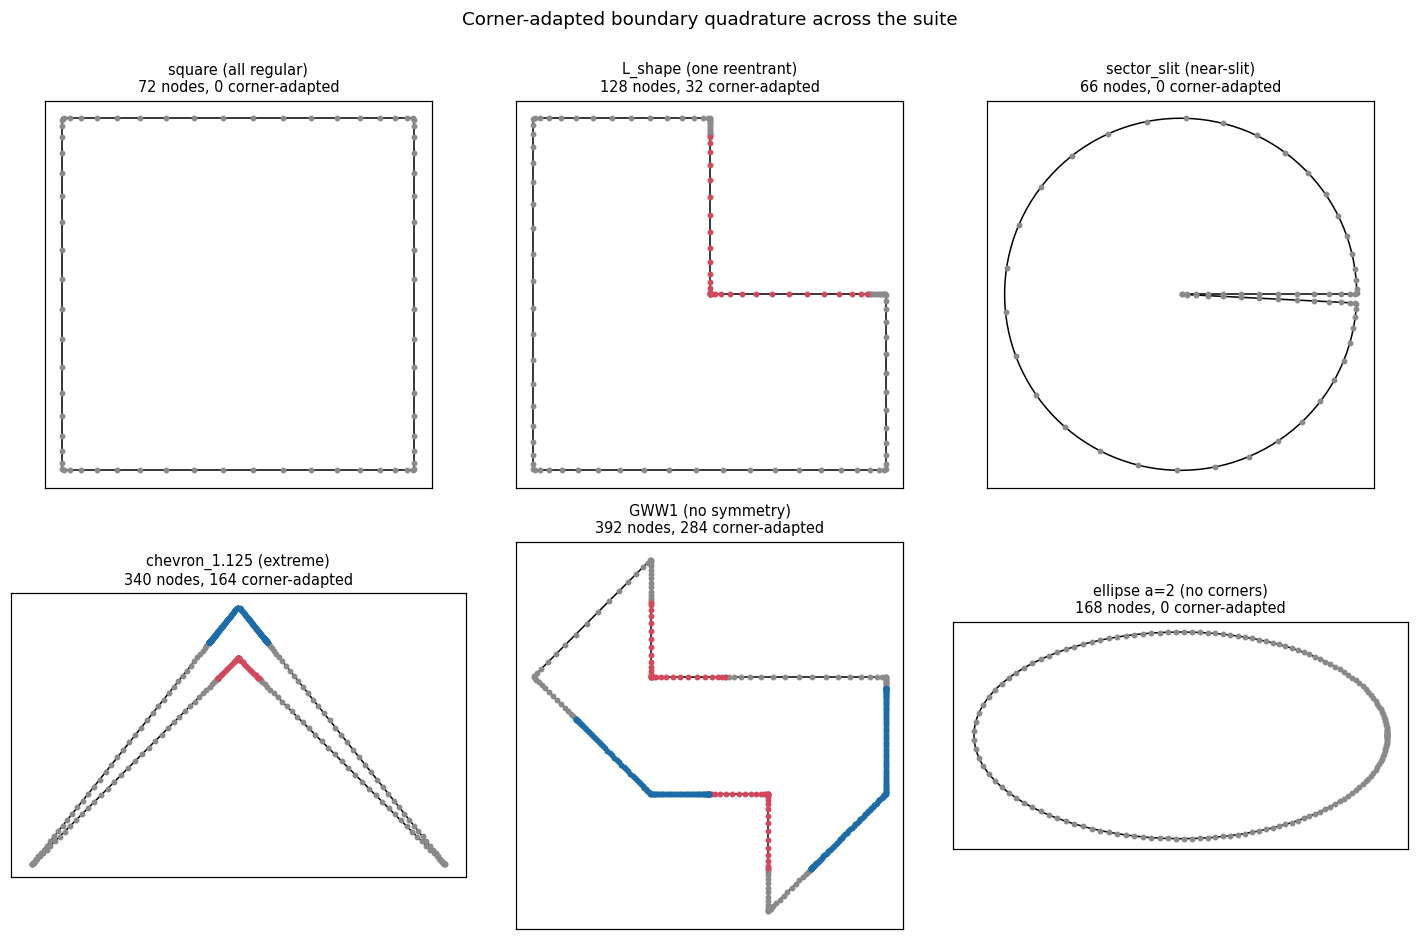

In [11]:

fig, axes = plt.subplots(2, 3, figsize=(13, 8.5))
for ax, (name, dom) in zip(axes.flat, gallery.items()):
    lam_max = weyl_est(6, dom)
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        bq = EI.boundary_quadrature(dom, lam_max)
    dom.plot(ax=ax, color='k', lw=1.0)
    panel_rule = np.array([bq.panels[pid].rule for pid in bq.panel_id])
    for rule, color in rule_colors.items():
        m = panel_rule == rule
        if m.any():
            ax.scatter(bq.pts.real[m], bq.pts.imag[m], s=8, color=color, zorder=3)
    ax.set_aspect('equal'); ax.set_xticks([]); ax.set_yticks([])
    n_corner_nodes = int((panel_rule != 'legendre').sum())
    ax.set_title(f"{name}\n{len(bq.pts)} nodes, {n_corner_nodes} corner-adapted", fontsize=9.5)
fig.suptitle('Corner-adapted boundary quadrature across the suite', y=1.0)
plt.tight_layout()
